In [11]:
# Alex Medina

In [12]:
# Imports

import os
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt

In [13]:
# 2a

datadir = "hw7_data/"
fext    = ".fits"

In [14]:
# 2b

objfile  = []
darkfile = []

for filename in os.listdir(datadir):
    if filename.startswith('stars_13s_'):
        file = filename.split(fext)[0]
        objfile.append(file)
    elif filename.startswith('dark_13s_'):
        file = filename.split(fext)[0]
        darkfile.append(file)

In [15]:
objfile, darkfile = sorted(objfile), sorted(darkfile)

In [16]:
# 2c

print(f"All contents of data are contained in the directory: {datadir}")
print(f"The extension of the files is {fext}")
print(f"The last element in the objfile is: {objfile[-1]}")
print(f"The last element in the darkfile is: {darkfile[-1]}")

All contents of data are contained in the directory: hw7_data/
The extension of the files is .fits
The last element in the objfile is: stars_13s_9
The last element in the darkfile is: dark_13s_5


In [17]:
# 2d

# Choosing a random indice from the list
randf = objfile[int(np.random.uniform(0, len(objfile)))]

# Getting file to read and shape
file = fits.getdata(datadir + randf + fext)
# Creating the shape
nx, ny = file.shape

In [18]:
# 2e

nobj  = len(objfile)
ndark = len(darkfile)

print(f"The size of a random file is nx = {nx}, ny = {ny}")
print(f"The number of fits files in objfile is: {nobj}")
print(f"The number of fits files in darkfile is: {ndark}")

The size of a random file is nx = 1024, ny = 1024
The number of fits files in objfile is: 9
The number of fits files in darkfile is: 5


In [41]:
# 3a

objarr  = np.zeros( (nobj, ny, nx), dtype=np.float64)
darkarr = np.zeros( (ndark, ny, nx), dtype=np.float64)

print(f"The shape of objarr array is: {objarr.shape}")
print(f"The shape of darkarr array is: {darkarr.shape}")

The shape of objarr array is: (9, 1024, 1024)
The shape of darkarr array is: (5, 1024, 1024)


In [61]:
# 3b

for i in range(nobj):
    if i < nobj - 1:
        objarr[i, :, :] = fits.getdata(datadir + objfile[i] + fext)
    else:
        objarr[i, :, :], objhead = fits.getdata(datadir + objfile[i] + fext, header=True)

for i in range(ndark):
    if i < ndark - 1:
        darkarr[i, :, :] = fits.getdata(datadir + darkfile[i] + fext)
    else:
        darkarr[i, :, :], darkhead = fits.getdata(datadir + darkfile[i] + fext, header=True)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1024                                                  NAXIS2  =                 1024                                                  OBJECT  = 'Praesepe'           /                                                ORIGIN  = 'Cornell-IR'         /                                                DATE-OBS= '2002-01-27'         / UTC from UNIX                                  TIME-OBS= '        '           / UTC from UNIX                                  OBSERVER= 'jcw,cph,jc,djb,sse' /                                                INSTRUME= 'WIRC    '           /                                                TELESCOP= 'Hale 200 inch'      /                                                TTFFILE = 'newWirc.ttf'        / FPGA Pr

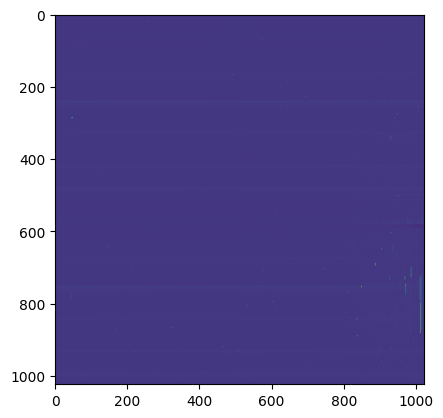

In [63]:
print(objhead)
plt.imshow(np.sum(darkarr, axis=0))

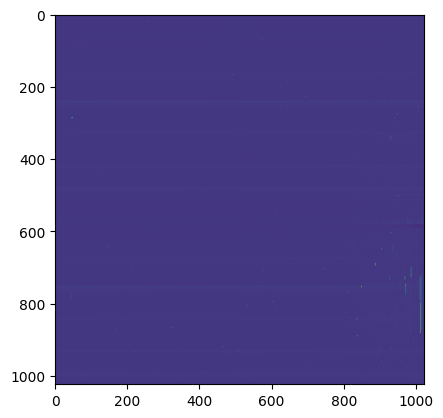

In [49]:
plt.imshow(np.sum(darkarr, axis=0))

In [ ]:
# 3c

print(
"""
You should not print TIME-OBS because fro looking at the header, there appears to be no TIME-OBS.
"""
)